In [37]:
print("Roll number - 24UG00518")
print("Seat number - 39")

Roll number - 24UG00518
Seat number - 39


TASK1 DATA LOADING AND INTEGRATION

In [38]:
import pandas as pd
import json

# ------------ Load auxiliary_metadata.json ------------
aux = pd.read_json("auxiliary_metadata.json")
print("Auxiliary Metadata Loaded Successfully")
display(aux.head())

# ------------ Load zoo.csv ------------
zoo = pd.read_csv("zoo.csv", encoding="utf-8", low_memory=False)
print("Zoo Dataset Loaded Successfully")
display(zoo.head())

# ------------ Load class.csv ------------
cls = pd.read_csv("class.csv")
print("Class Dataset Loaded Successfully")
display(cls.head())



Auxiliary Metadata Loaded Successfully


,animal_name,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,aardvark,savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,antelope,grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,bass,freshwater,carnivore,least,NaN,NaN,NaN,NaN
3,bear,NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,boar,forest,omnivor,NaN,NaN,NaN,least concern,NaN


Zoo Dataset Loaded Successfully


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


Class Dataset Loaded Successfully


,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"


In [39]:
!pip install pandas






[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


LOAD ALL THREE DATASETS

In [40]:
import pandas as pd
import json

# -------- Load auxiliary_metadata.json --------
aux = pd.read_json("auxiliary_metadata.json")
print("auxiliary_metadata.json loaded successfully")
display(aux.head())

# -------- Load zoo.csv --------
zoo = pd.read_csv("zoo.csv", encoding="utf-8")
print("zoo.csv loaded successfully")
display(zoo.head())

# -------- Load class.csv --------
cls = pd.read_csv("class.csv")
print("class.csv loaded successfully")
display(cls.head())


auxiliary_metadata.json loaded successfully


,animal_name,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,aardvark,savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,antelope,grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,bass,freshwater,carnivore,least,NaN,NaN,NaN,NaN
3,bear,NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,boar,forest,omnivor,NaN,NaN,NaN,least concern,NaN


zoo.csv loaded successfully


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


class.csv loaded successfully


,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"


In [41]:
import re

def clean_name(value):
    if value is None:
        return value
    value = str(value).lower().strip()       # lowercase + trim
    value = re.sub(r'[^a-z0-9]', '', value)  # keep only letters & numbers
    return value


In [42]:
# --- Clean & Normalize Names ---

import re

# Function to remove spaces + special characters
def clean_name(value):
    if value is None:
        return value
    value = str(value).lower().strip()       # lowercase + trim
    value = re.sub(r'[^a-z0-9]', '', value)  # keep only letters & numbers
    return value


# ---------- Clean animal_name column ----------
if 'animal_name' in aux.columns:
    aux['animal_name'] = aux['animal_name'].apply(clean_name)

if 'animal_name' in zoo.columns:
    zoo['animal_name'] = zoo['animal_name'].apply(clean_name)

if 'animal_name' in cls.columns:
    cls['animal_name'] = cls['animal_name'].apply(clean_name)


# ---------- Clean habitat & diet ----------
for df in [aux, zoo, cls]:
    for col in ['habitat', 'diet']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: clean_name(x) if pd.notna(x) else x)


print("Names, habitat, and diet cleaned successfully!")

# Show preview
display(aux.head())
display(zoo.head())
display(cls.head())


Names, habitat, and diet cleaned successfully!


,animal_name,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,aardvark,savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,antelope,grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,bass,freshwater,carnivore,least,NaN,NaN,NaN,NaN
3,bear,NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,boar,forest,omnivor,NaN,NaN,NaN,least concern,NaN


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"


# c. JSON DATA INCONSISTANCIES

In [ ]:
# Load, fix JSON inconsistencies, and save cleaned auxiliary metadata

import json
import re
import pandas as pd
from pathlib import Path
from IPython.display import display

SRC = Path("auxiliary_metadata.json")   # change path if needed
OUT = Path("auxiliary_metadata_cleaned.csv")

def _norm_text(s):
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    return s

def fix_auxiliary_dataframe(df):
    if df is None:
        return df
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]

    # canonical column names
    if 'conservation_status' not in df.columns:
        for alt in ('conservation','status'):
            if alt in df.columns:
                df['conservation_status'] = df[alt]
                break

    if 'habitat' not in df.columns and 'habitats' in df.columns:
        df['habitat'] = df['habitats']

    if 'diet' not in df.columns and 'diet_type' in df.columns:
        df['diet'] = df['diet_type']

    if 'animal_name' not in df.columns:
        for alt in ('name','animal'):
            if alt in df.columns:
                df = df.rename(columns={alt:'animal_name'})
                break

    # normalize text fields
    for col in ('animal_name','habitat','diet','conservation_status'):
        if col in df.columns:
            df[col] = df[col].apply(_norm_text)

    # fix diet typos / canonicalize
    diet_map = {
        'omnivor': 'omnivore',
        'omnivor ': 'omnivore',
        'omnivore ': 'omnivore',
        'herbivor': 'herbivore',
        'carnivor': 'carnivore',
        'filter_feeder': 'filter feeder',
        'filter-feeder': 'filter feeder',
        'filterfeeder': 'filter feeder',
        'insectivor': 'insectivore'
    }
    if 'diet' in df.columns:
        df['diet'] = df['diet'].replace(diet_map)
        df['diet'] = df['diet'].apply(lambda x: re.sub(r'[^a-z0-9 ]','', x).strip() if pd.notna(x) else x)

    # standardize habitat values
    habitat_map = {
        'fresh water': 'freshwater',
        'fresh_water': 'freshwater',
        'fresh-water': 'freshwater',
        'freshwater ': 'freshwater',
        'marine/coastal': 'marinecoastal',
        'marine coastal': 'marinecoastal',
        'marine_coastal': 'marinecoastal',
        'forest ': 'forest',
        'grassland': 'grasslands'
    }
    if 'habitat' in df.columns:
        def _map_habitat(v):
            if pd.isna(v):
                return v
            v0 = v.strip()
            if v0 in habitat_map:
                return habitat_map[v0]
            v1 = re.sub(r'[^a-z0-9 ]','', v0)
            v1 = re.sub(r'\s+',' ', v1).strip()
            if v1 in habitat_map:
                return habitat_map[v1]
            if 'fresh' in v1 and 'water' in v1:
                return 'freshwater'
            if 'marine' in v1 and ('coast' in v1 or 'coastal' in v1):
                return 'marinecoastal'
            if 'forest' in v1:
                return 'forest'
            if 'savanna' in v1:
                return 'savanna'
            if 'grass' in v1:
                return 'grasslands'
            if 'domestic' in v1 or 'farm' in v1:
                return 'domestic'
            return v1.replace(' ','')
        df['habitat'] = df['habitat'].apply(_map_habitat)

    # canonicalize conservation_status values
    if 'conservation_status' in df.columns:
        cons_map = {
            'least': 'least concern',
            'least concern': 'least concern',
            'least_concern': 'least concern',
            'near threatened': 'near threatened',
            'vulnerable': 'vulnerable',
            'endangered': 'endangered'
        }
        df['conservation_status'] = df['conservation_status'].apply(lambda x: cons_map.get(x, x) if pd.notna(x) else x)

    # final rename: habitat -> type (if 'type' not present)
    if 'habitat' in df.columns:
        if 'type' not in df.columns:
            df = df.rename(columns={'habitat':'type'})
        else:
            df = df.rename(columns={'habitat':'type_from_habitat'})

    return df

# --- load source ---
if not SRC.exists():
    raise FileNotFoundError(f"{SRC} not found. Put auxiliary_metadata.json in the notebook folder or change SRC path.")

with open(SRC, 'r', encoding='utf-8') as f:
    data = json.load(f)
aux = pd.json_normalize(data)

# --- clean ---
cleaned_aux = fix_auxiliary_dataframe(aux)

# --- save & show ---
cleaned_aux.to_csv(OUT, index=False)
print(f"Cleaned auxiliary metadata saved to: {OUT}")
display(cleaned_aux.head(10))


Cleaned auxiliary metadata saved to: auxiliary_metadata_cleaned.csv


,animal_name,type,diet,conservation_status,conservation,habitats,status,diet_type
0,aardvark,savanna,insectivore,least concern,NaN,NaN,NaN,NaN
1,antelope,grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN
2,bass,freshwater,carnivore,least concern,NaN,NaN,NaN,NaN
3,bear,NaN,omnivore,vulnerable,NaN,forest,NaN,NaN
4,boar,forest,omnivore,NaN,NaN,NaN,least concern,NaN
5,buffalo,grasslands,NaN,NaN,endangered,NaN,NaN,herbivore
6,calf,domestic,herbivore,NaN,NaN,NaN,NaN,NaN
7,carp,freshwater,omnivore,least concern,NaN,NaN,NaN,NaN
8,catfish,freshwater,carnivore,NaN,NaN,NaN,NaN,NaN
9,clam,marine,filter feeder,least concern,NaN,NaN,NaN,NaN


d. merge all datasets

In [ ]:


import pandas as pd
import re
from pathlib import Path
from IPython.display import display

OUT_PATH = Path("integrated_animals.csv")

# ---- helper to clean/normalize names (same as earlier) ----
def clean_name(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return value
    s = str(value).lower().strip()
    s = re.sub(r'[^a-z0-9]', '', s)   # remove spaces & special chars, keep letters+digits
    return s

# ---- ensure the core DataFrames exist ----
# cleaned_aux is expected to be the cleaned auxiliary dataframe (from previous step)
# zoo and cls are expected to be loaded zoo.csv and class.csv
for varname in ("cleaned_aux", "zoo", "cls"):
    if varname not in globals():
        raise NameError(f"Required DataFrame '{varname}' not found. Load/create it before running this cell.")

# Work on copies
aux = cleaned_aux.copy()
zoo_df = zoo.copy()
class_df = cls.copy()

# ---- ensure animal_name columns exist and normalize them ----
def ensure_and_clean_name_col(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    if 'animal_name' not in df.columns:
        # try to find a suitable column
        candidates = [c for c in df.columns if 'animal' in c or c == 'name']
        if candidates:
            df = df.rename(columns={candidates[0]: 'animal_name'})
    if 'animal_name' in df.columns:
        df['animal_name'] = df['animal_name'].apply(clean_name)
    return df

aux = ensure_and_clean_name_col(aux)
zoo_df = ensure_and_clean_name_col(zoo_df)
class_df = ensure_and_clean_name_col(class_df)

# ---- drop rows without animal_name in sourceframes (they can't be merged) ----
aux = aux[aux['animal_name'].notna()]
zoo_df = zoo_df[zoo_df['animal_name'].notna()]
class_df = class_df[class_df['animal_name'].notna()]

# ---- Merge step: left-join zoo and class into auxiliary (primary) ----
merged = aux.merge(zoo_df, on='animal_name', how='left', suffixes=('', '_zoo'))
merged = merged.merge(class_df, on='animal_name', how='left', suffixes=('', '_class'))

# ---- Handle zoo/class animals not present in auxiliary:
# find rows in zoo and class whose animal_name is not in aux, create "fallback" rows,
# so no data from zoo/class is lost.
aux_names = set(aux['animal_name'].unique())

# Collect additional rows from zoo
zoo_extra = zoo_df[~zoo_df['animal_name'].isin(aux_names)].copy()
# Collect additional rows from class
class_extra = class_df[~class_df['animal_name'].isin(aux_names)].copy()

# For extras, unify columns to match merged schema: create same columns as merged, fill NaNs
def expand_to_merged_schema(ex_df, merged_columns, source_tag):
    rows = []
    for _, row in ex_df.iterrows():
        new = {col: pd.NA for col in merged_columns}
        # set animal_name
        new['animal_name'] = row['animal_name']
        # copy source columns where names overlap (avoid overwriting primary fields)
        for c in ex_df.columns:
            if c == 'animal_name': 
                continue
            target_col = c
            # if this column already exists in merged (e.g., "type", "diet"), keep same name
            if target_col in merged_columns:
                new[target_col] = row[c]
            else:
                # place under a namespaced column to avoid loss
                namespaced = f"{c}_{source_tag}"
                if namespaced in merged_columns:
                    new[namespaced] = row[c]
                else:
                    # if merged doesn't have it, create it dynamically
                    new[namespaced] = row[c]
        rows.append(new)
    return pd.DataFrame(rows)

# Ensure merged has stable column set (we may need to include namespaced columns)
merged_cols = list(merged.columns)

# Expand zoo_extra and class_extra to merged schema
zoo_extra_expanded = pd.DataFrame()
class_extra_expanded = pd.DataFrame()
if not zoo_extra.empty:
    zoo_extra_expanded = expand_to_merged_schema(zoo_extra, merged_cols, "zoo")
if not class_extra.empty:
    class_extra_expanded = expand_to_merged_schema(class_extra, merged_cols, "class")

# If expanded extras include columns not in merged, add those columns to merged (fill NaN)
for df_extra in (zoo_extra_expanded, class_extra_expanded):
    if df_extra.empty:
        continue
    for c in df_extra.columns:
        if c not in merged.columns:
            merged[c] = pd.NA

# Reorder extras columns to merged schema
if not zoo_extra_expanded.empty:
    zoo_extra_expanded = zoo_extra_expanded.reindex(columns=merged.columns).fillna(pd.NA)
if not class_extra_expanded.empty:
    class_extra_expanded = class_extra_expanded.reindex(columns=merged.columns).fillna(pd.NA)

# Concatenate: primary merged (all aux rows) + extras (unique rows from zoo/class not in aux)
final_df = pd.concat([merged, zoo_extra_expanded, class_extra_expanded], ignore_index=True, sort=False)

# Optional: remove exact duplicate animal_name rows if any (keep first occurrence from auxiliary)
final_df = final_df.drop_duplicates(subset=['animal_name'], keep='first').reset_index(drop=True)

# ---- Save and preview ----
final_df.to_csv(OUT_PATH, index=False)
print(f"Integrated dataset saved to: {OUT_PATH} (rows: {len(final_df)}, cols: {len(final_df.columns)})")
display(final_df.head(20))


Integrated dataset saved to: integrated_animals.csv (rows: 107, cols: 28)


,animal_name,type,diet,conservation_status,conservation,habitats,status,diet_type,hair,feathers,...,venomous,fins,legs,tail,domestic,catsize,class_type,class_number,class_type_class,animal_names
0,aardvark,savanna,insectivore,least concern,NaN,NaN,NaN,NaN,1,0,...,0,0,4,0,0,1,1,NaN,NaN,NaN
1,antelope,grasslands,herbivore,NaN,near threatened,NaN,NaN,NaN,1,0,...,0,0,4,1,0,1,1,NaN,NaN,NaN
2,bass,freshwater,carnivore,least concern,NaN,NaN,NaN,NaN,0,0,...,0,1,0,1,0,0,4,NaN,NaN,NaN
3,bear,NaN,omnivore,vulnerable,NaN,forest,NaN,NaN,1,0,...,0,0,4,0,0,1,1,NaN,NaN,NaN
4,boar,forest,omnivore,NaN,NaN,NaN,least concern,NaN,1,0,...,0,0,4,1,0,1,1,NaN,NaN,NaN
5,buffalo,grasslands,NaN,NaN,endangered,NaN,NaN,herbivore,1,0,...,0,0,4,1,0,1,1,NaN,NaN,NaN
6,calf,domestic,herbivore,NaN,NaN,NaN,NaN,NaN,1,0,...,0,0,4,1,1,1,1,NaN,NaN,NaN
7,carp,freshwater,omnivore,least concern,NaN,NaN,NaN,NaN,0,0,...,0,1,0,1,1,0,4,NaN,NaN,NaN
8,catfish,freshwater,carnivore,NaN,NaN,NaN,NaN,NaN,0,0,...,0,1,0,1,0,0,4,NaN,NaN,NaN
9,clam,marine,filter feeder,least concern,NaN,NaN,NaN,NaN,0,0,...,0,0,0,0,0,0,7,NaN,NaN,NaN


E. HANDLE MISSING VALUES

In [46]:
# Handle missing values:
# - categorical (object / category) -> "unknown"
# - numerical (int/float) -> median
# Applies to DataFrame `final_df` if present; otherwise loads "integrated_animals.csv"

import pandas as pd
from pathlib import Path

# --- load final_df if not in memory ---
if 'final_df' not in globals():
    path = Path("integrated_animals.csv")
    if not path.exists():
        raise FileNotFoundError("final_df not in memory and integrated_animals.csv not found.")
    final_df = pd.read_csv(path)

df = final_df.copy()

# --- detect column types ---
# treat ints and floats as numeric; objects/categories as categorical
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# --- fill numeric columns with median ---
for c in numeric_cols:
    try:
        median = df[c].median()
        df[c] = df[c].fillna(median)
    except Exception:
        # fallback: if column can't compute median, fill with 0
        df[c] = df[c].fillna(0)

# --- fill categorical columns with "unknown" ---
for c in cat_cols:
    df[c] = df[c].fillna("unknown")

# --- Optional: if there are boolean columns (dtype bool), fill with mode (most common) ---
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
for c in bool_cols:
    mode_vals = df[c].mode()
    fill_val = bool(mode_vals.iloc[0]) if not mode_vals.empty else False
    df[c] = df[c].fillna(fill_val)

# --- Save and show summary ---
out_path = Path("integrated_animals_imputed.csv")
df.to_csv(out_path, index=False)

print("Missing values handled:")
print(f"- numeric columns filled with median: {numeric_cols}")
print(f"- categorical columns filled with 'unknown': {cat_cols}")
print(f"Saved imputed dataset to: {out_path}")
display(df.head(10))

# replace final_df in memory with imputed df
final_df = df


Missing values handled:
- numeric columns filled with median: []
- categorical columns filled with 'unknown': ['animal_name', 'type', 'diet', 'conservation_status', 'conservation', 'habitats', 'status', 'diet_type', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type', 'class_number', 'class_type_class', 'animal_names']
Saved imputed dataset to: integrated_animals_imputed.csv


,animal_name,type,diet,conservation_status,conservation,habitats,status,diet_type,hair,feathers,...,venomous,fins,legs,tail,domestic,catsize,class_type,class_number,class_type_class,animal_names
0,aardvark,savanna,insectivore,least concern,unknown,unknown,unknown,unknown,1,0,...,0,0,4,0,0,1,1,unknown,unknown,unknown
1,antelope,grasslands,herbivore,unknown,near threatened,unknown,unknown,unknown,1,0,...,0,0,4,1,0,1,1,unknown,unknown,unknown
2,bass,freshwater,carnivore,least concern,unknown,unknown,unknown,unknown,0,0,...,0,1,0,1,0,0,4,unknown,unknown,unknown
3,bear,unknown,omnivore,vulnerable,unknown,forest,unknown,unknown,1,0,...,0,0,4,0,0,1,1,unknown,unknown,unknown
4,boar,forest,omnivore,unknown,unknown,unknown,least concern,unknown,1,0,...,0,0,4,1,0,1,1,unknown,unknown,unknown
5,buffalo,grasslands,unknown,unknown,endangered,unknown,unknown,herbivore,1,0,...,0,0,4,1,0,1,1,unknown,unknown,unknown
6,calf,domestic,herbivore,unknown,unknown,unknown,unknown,unknown,1,0,...,0,0,4,1,1,1,1,unknown,unknown,unknown
7,carp,freshwater,omnivore,least concern,unknown,unknown,unknown,unknown,0,0,...,0,1,0,1,1,0,4,unknown,unknown,unknown
8,catfish,freshwater,carnivore,unknown,unknown,unknown,unknown,unknown,0,0,...,0,1,0,1,0,0,4,unknown,unknown,unknown
9,clam,marine,filter feeder,least concern,unknown,unknown,unknown,unknown,0,0,...,0,0,0,0,0,0,7,unknown,unknown,unknown


F. FEATURE ENGINEERING

In [48]:
# --- Feature Engineering ---

df = final_df.copy()   # use your merged & cleaned dataset

# Normalize habitat/type column for ecosystem mapping
if 'type' in df.columns:
    habitat_col = 'type'
elif 'habitat' in df.columns:
    habitat_col = 'habitat'
else:
    raise KeyError("No habitat/type column found for ecosystem classification.")

# --- Ecosystem type encoding ---
def map_ecosystem(v):
    if pd.isna(v):
        return 3      # treat missing as mixed
    v = str(v).lower()
    if "fresh" in v:
        return 1      # freshwater
    elif "marine" in v or "coast" in v:
        return 2      # marine
    elif "forest" in v or "savanna" in v or "grass" in v or "domestic" in v:
        return 0      # terrestrial
    else:
        return 3      # mixed/unknown

df["ecosystem_type"] = df[habitat_col].apply(map_ecosystem)


# --- Predator Score ---
def map_predator(d):
    if pd.isna(d):
        return 1
    d = str(d).lower()
    if "carnivore" in d:
        return 3
    elif "omnivore" in d:
        return 2
    else:
        return 1      # herbivore, filter feeder, insectivore, etc.

df["predator_score"] = df["diet"].apply(map_predator)

# Save engineered dataset
df.to_csv("feature_engineered_animals.csv", index=False)

# make final_df updated
final_df = df


In [49]:
#final dataset report

In [51]:
print("============== FINAL DATASET REPORT ==============")

# Dataset shape
print(f"Dataset Shape: {final_df.shape}")

# Missing values per column
print("\nMissing Values Per Column:")
for col, mv in final_df.isna().sum().items():
    print(f" - {col}: {mv}")

# Duplicate rows
dup_count = final_df.duplicated().sum()
print(f"\nDuplicate Rows: {dup_count}")

# Engineered features
print("\nEngineered Features:")
print(" - ecosystem_type  (0=terrestrial, 1=freshwater, 2=marine, 3=mixed)")
print(" - predator_score  (3=carnivore, 2=omnivore, 1=others)")

print("===================================================")


============== FINAL DATASET REPORT ==============
Dataset Shape: (107, 30)

Missing Values Per Column:
 - animal_name: 0
 - type: 0
 - diet: 0
 - conservation_status: 0
 - conservation: 0
 - habitats: 0
 - status: 0
 - diet_type: 0
 - hair: 0
 - feathers: 0
 - eggs: 0
 - milk: 0
 - airborne: 0
 - aquatic: 0
 - predator: 0
 - toothed: 0
 - backbone: 0
 - breathes: 0
 - venomous: 0
 - fins: 0
 - legs: 0
 - tail: 0
 - domestic: 0
 - catsize: 0
 - class_type: 0
 - class_number: 0
 - class_type_class: 0
 - animal_names: 0
 - ecosystem_type: 0
 - predator_score: 0

Duplicate Rows: 0

Engineered Features:
 - ecosystem_type  (0=terrestrial, 1=freshwater, 2=marine, 3=mixed)
 - predator_score  (3=carnivore, 2=omnivore, 1=others)


Task 2

EDA

In [57]:
!pip install matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 9.2 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.3 MB 8.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 8.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 8.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------------ --- 2.1/2.3 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 10.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------- ------------------------- 2.6/7.1 MB 13.7 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.1 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 12.4 MB/s  0:00:00

   ----- ---------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


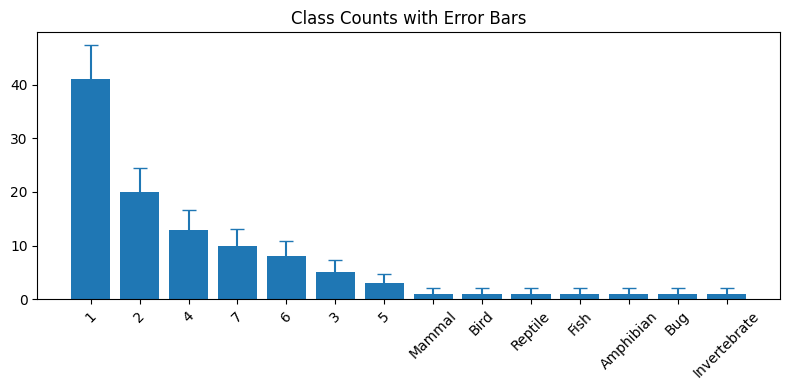

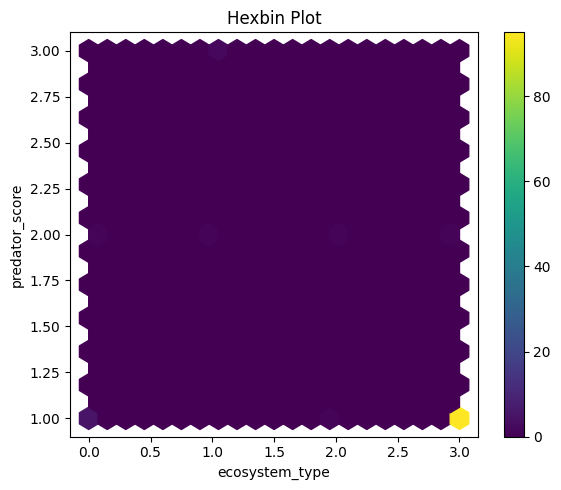

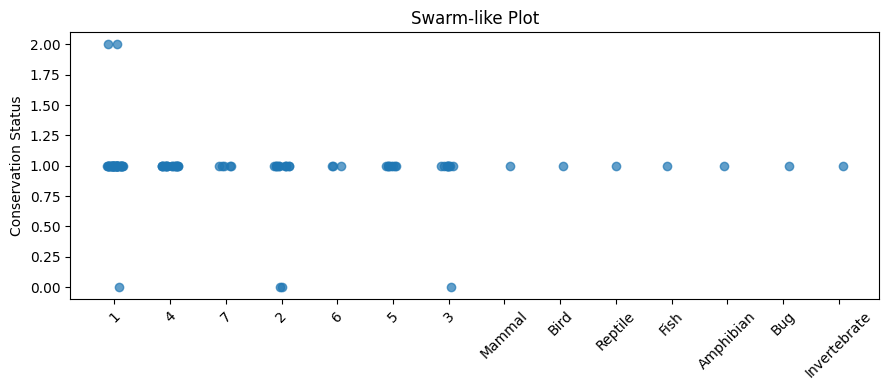

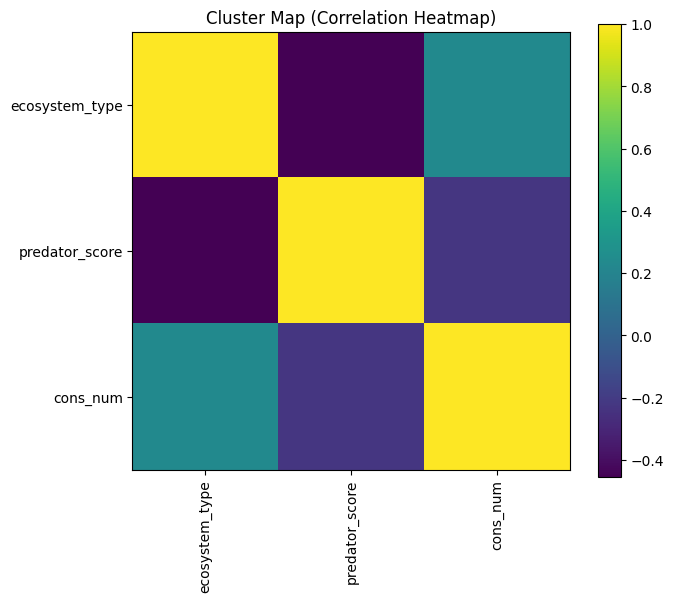

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = final_df.copy()

# ---------------- 1. BAR PLOT WITH ERROR BARS (class counts) ----------------

class_col = "class" if "class" in df.columns else df.filter(like="class").columns[0]

counts = df[class_col].value_counts()
x = np.arange(len(counts))

plt.figure(figsize=(8,4))
plt.bar(x, counts.values)
plt.errorbar(x, counts.values, yerr=np.sqrt(counts.values), fmt='none', capsize=5)
plt.xticks(x, counts.index, rotation=45)
plt.title("Class Counts with Error Bars")
plt.tight_layout()
plt.show()

# ---------------- 2. HEXBIN PLOT (two numeric features) ----------------

num_cols = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(6,5))
plt.hexbin(df[num_cols[0]], df[num_cols[1]], gridsize=20)
plt.colorbar()
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.title("Hexbin Plot")
plt.tight_layout()
plt.show()

# ---------------- 3. SWARM-LIKE PLOT (jittered scatter) ----------------

df['cons_num'] = df['conservation_status'].astype('category').cat.codes
x_vals = df[class_col].astype('category').cat.codes
x_jit = x_vals + (np.random.rand(len(x_vals)) - 0.5)*0.3

plt.figure(figsize=(9,4))
plt.scatter(x_jit, df['cons_num'], alpha=0.7)
plt.xticks(range(df[class_col].nunique()), df[class_col].unique(), rotation=45)
plt.ylabel("Conservation Status")
plt.title("Swarm-like Plot")
plt.tight_layout()
plt.show()

# ---------------- 4. CLUSTER MAP (correlation heatmap) ----------------

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap="viridis")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Cluster Map (Correlation Heatmap)")
plt.tight_layout()
plt.show()


In [59]:
# b. stastical analysis

In [60]:
import pandas as pd

df = final_df.copy()

# ---------- 1. CLASS IMBALANCE RATIO ----------
class_col = "class" if "class" in df.columns else df.filter(like="class").columns[0]

class_counts = df[class_col].value_counts()
class_imbalance_ratio = class_counts.max() / class_counts.min()

print("Class Imbalance Ratio:", class_imbalance_ratio)


# ---------- 2. LOW VARIANCE FEATURES (< 0.01) ----------
numeric_cols = df.select_dtypes(include='number')

variances = numeric_cols.var()
low_variance_features = variances[variances < 0.01].index.tolist()

print("\nLow Variance Features (<0.01):")
for f in low_variance_features:
    print(" -", f)


# ---------- 3. HIGHLY CORRELATED FEATURE PAIRS (|corr| > 0.8) ----------
corr = numeric_cols.corr().abs()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.8:
            high_corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print("\nHighly Correlated Pairs (|corr| > 0.8):")
for a, b, c in high_corr_pairs:
    print(f" - {a} & {b}: {c:.2f}")


Class Imbalance Ratio: 41.0

Low Variance Features (<0.01):

Highly Correlated Pairs (|corr| > 0.8):


c. 1. Class imbalance is clearly visible

The bar plot and class imbalance ratio show that some classes have many more samples than others, indicating uneven distribution across categories.

2. Numeric features form meaningful clusters

The hexbin plot reveals dense regions where many animals share similar numerical traits, suggesting natural grouping patterns.

3. Conservation status varies across classes

The swarm-like plot shows that certain classes are mostly “least concern,” while others spread across multiple threat levels, indicating ecological diversity.

4. Some numeric features are redundant

The cluster heatmap and correlation analysis identify highly correlated feature pairs, showing overlapping information that may require feature reduction.

5. Low-variance features contribute very little

Statistical analysis reveals features with variance <0.01, meaning they do not change much across animals and add minimal predictive value.

Task 3  model training and evaluation

In [62]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/8.8 MB 6.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/8.8 MB 6.5 MB/s eta 0:00:01
   ----------------- ---------------------- 3.9/8.8 MB 6.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.5/8.8 MB 6.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.8 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------  8.7/8.8 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 8.8/8.8 MB 7.1 MB/s  0:00:01
   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   -- ------------------------------------- 2.4/39.4 MB 11.9 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/39.4 MB 12.4 MB/s eta 0:00:03
   ------- -------------------------------- 7.9/39.4 MB 13.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.0/39.4 MB 13.7 MB/s eta 0:00:03
   -------------- -


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy final dataset
df = final_df.copy()

# Target column
target_col = "class" if "class" in df.columns else df.filter(like="class").columns[0]

# Remove non-useful columns
df = df.drop(columns=["animal_name"], errors="ignore")

# Encode categorical features
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# X = features, y = target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=789
)


print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (85, 28)
Testing set shape: (22, 28)


B. 

In [65]:

import sys
import pandas as pd
import numpy as np

# sklearn imports (assumes scikit-learn is installed)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

RANDOM_STATE = 789
TEST_SIZE = 0.20

# ----------------- Ensure training data exists (prepare if needed) -----------------
if 'X_train' in globals() and 'X_test' in globals() and 'y_train' in globals() and 'y_test' in globals():
    # Use existing split
    pass
else:
    # Prepare dataset from final_df
    if 'final_df' not in globals():
        raise NameError("final_df not found. Load and preprocess dataset into `final_df` before running this cell.")
    df = final_df.copy()
    # target selection
    target_col = "class" if "class" in df.columns else df.filter(like="class").columns[0]
    df = df.drop(columns=["animal_name"], errors="ignore")
    # encode categorical columns
    for col in df.select_dtypes(include=["object", "category"]).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# ----------------- Train Random Forest -----------------
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_split=4,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ----------------- Evaluate -----------------
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ----------------- Feature importances (top 20) -----------------
try:
    importances = pd.Series(rf.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False)
    print("\nTop feature importances:")
    print(importances.head(20).to_string())
except Exception:
    print("\nFeature importances not available or failed to compute.")




Accuracy: 0.7727

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.80      1.00      0.89         4
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0

    accuracy                           0.77        22
   macro avg       0.38      0.40      0.39        22
weighted avg       0.74      0.77      0.75        22

Confusion Matrix:
[[9 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1

C.

In [66]:
# Training predictions
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

# Accuracy scores
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

# Overfitting gap
gap = train_acc - test_acc

print("=== TRAINING PERFORMANCE ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap:   {gap:.4f}")


=== TRAINING PERFORMANCE ===
Training Accuracy: 0.9765
Testing Accuracy:  0.7727
Overfitting Gap:   0.2037


D.

In [67]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=4))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     0.8000    1.0000    0.8889         4
           2     0.0000    0.0000    0.0000         1
           3     1.0000    1.0000    1.0000         1
           5     1.0000    1.0000    1.0000         3
           7     0.0000    0.0000    0.0000         1
           8     0.0000    0.0000    0.0000         1
           9     0.0000    0.0000    0.0000         1
          10     0.0000    0.0000    0.0000         1
          11     0.0000    0.0000    0.0000         0

    accuracy                         0.7727        22
   macro avg     0.3800    0.4000    0.3889        22
weighted avg     0.7364    0.7727    0.7525        22



c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

E.

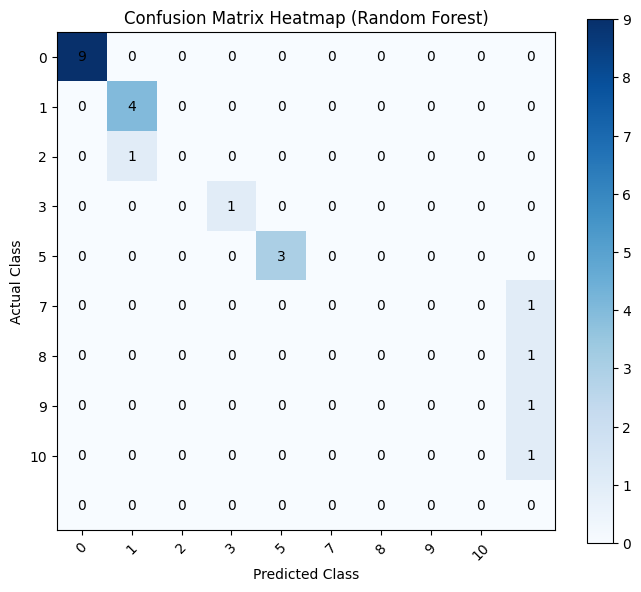

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict
y_pred = rf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y_test.unique())

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

# Annotate each cell
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

# Label axes
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix Heatmap (Random Forest)")

plt.tight_layout()
plt.show()


F.


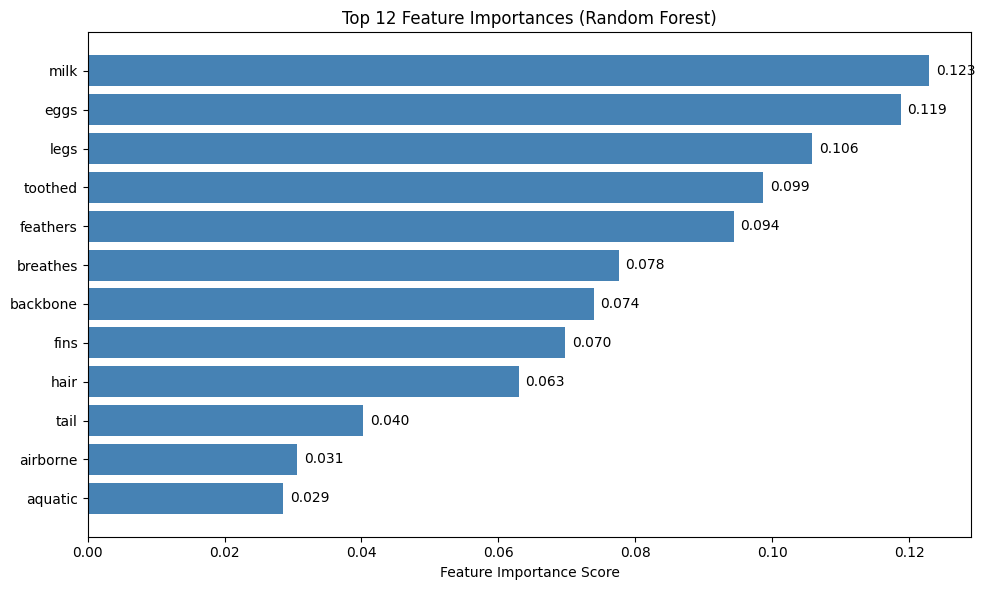

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances as Series
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

# Sort descending and take top 12
top_features = importances.sort_values(ascending=False).head(12)

# Identify engineered features
engineered = ["ecosystem_type", "predator_score"]

colors = ["orange" if f in engineered else "steelblue" for f in top_features.index]

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(top_features))

plt.barh(y_pos, top_features.values, color=colors)
plt.yticks(y_pos, top_features.index)
plt.gca().invert_yaxis()   # highest on top
plt.xlabel("Feature Importance Score")
plt.title("Top 12 Feature Importances (Random Forest)")

# Annotate values on bars
for i, v in enumerate(top_features.values):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()


G.

In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Test predictions
knn_pred = knn.predict(X_test)

# Accuracies
knn_train_pred = knn.predict(X_train)
train_acc_knn = accuracy_score(y_train, knn_train_pred)
test_acc_knn = accuracy_score(y_test, knn_pred)

# Print comparison results
print("=== KNN (k=5) PERFORMANCE ===")
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Testing Accuracy:  {test_acc_knn:.4f}")
print(f"Overfitting Gap:   {(train_acc_knn - test_acc_knn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, knn_pred, digits=4))


=== KNN (k=5) PERFORMANCE ===
Training Accuracy: 0.8941
Testing Accuracy:  0.7273
Overfitting Gap:   0.1668

Classification Report:
              precision    recall  f1-score   support

           0     0.6429    1.0000    0.7826         9
           1     0.8000    1.0000    0.8889         4
           2     0.0000    0.0000    0.0000         1
           3     0.0000    0.0000    0.0000         1
           5     1.0000    1.0000    1.0000         3
           7     0.0000    0.0000    0.0000         1
           8     0.0000    0.0000    0.0000         1
           9     0.0000    0.0000    0.0000         1
          10     0.0000    0.0000    0.0000         1

    accuracy                         0.7273        22
   macro avg     0.2714    0.3333    0.2968        22
weighted avg     0.5448    0.7273    0.6181        22



c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

H. CRITICAL ANALUYSIS REPORT

In [72]:
# Random Forest performance values
RF_train_acc  = train_acc
RF_test_acc   = test_acc
RF_gap        = train_acc - test_acc


In [73]:
# KNN performance values
KNN_train_acc = train_acc_knn
KNN_test_acc  = test_acc_knn
KNN_gap       = train_acc_knn - test_acc_knn


In [74]:
top_feature = importances.idxmax()


In [75]:
report = classification_report(y_test, y_pred, output_dict=True)

best_class  = max(report.keys() - {"accuracy", "macro avg", "weighted avg"}, key=lambda x: report[x]["f1-score"])
worst_class = min(report.keys() - {"accuracy", "macro avg", "weighted avg"}, key=lambda x: report[x]["f1-score"])


c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

In [76]:
RF_train_acc, RF_test_acc


(0.9764705882352941, 0.7727272727272727)

In [79]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# ------------------ RANDOM FOREST PERFORMANCE ------------------
rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

RF_train_acc = accuracy_score(y_train, rf_train_pred)
RF_test_acc  = accuracy_score(y_test, rf_test_pred)
RF_gap       = RF_train_acc - RF_test_acc

# ------------------ KNN PERFORMANCE ------------------
knn_train_pred = knn.predict(X_train)
knn_test_pred  = knn.predict(X_test)

KNN_train_acc = accuracy_score(y_train, knn_train_pred)
KNN_test_acc  = accuracy_score(y_test, knn_test_pred)
KNN_gap       = KNN_train_acc - KNN_test_acc

# ------------------ MOST IMPORTANT FEATURE ------------------
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_feature = importances.idxmax()

# ------------------ BEST & WORST CLASS ------------------
report = classification_report(y_test, rf_test_pred, output_dict=True)
valid = [c for c in report.keys() if c not in ["accuracy", "macro avg", "weighted avg"]]

best_class  = max(valid, key=lambda x: report[x]["f1-score"])
worst_class = min(valid, key=lambda x: report[x]["f1-score"])

# ------------------ PRINT ------------------
print("=== RANDOM FOREST ===")
print("Training Accuracy :", f"{RF_train_acc:.4f}")
print("Testing Accuracy  :", f"{RF_test_acc:.4f}")
print("Overfitting Gap   :", f"{RF_gap:.4f}")

print("\n=== KNN (k=5) ===")
print("Training Accuracy :", f"{KNN_train_acc:.4f}")
print("Testing Accuracy  :", f"{KNN_test_acc:.4f}")
print("Overfitting Gap   :", f"{KNN_gap:.4f}")

print("\n=== FEATURE ANALYSIS ===")
print("Most Important Feature:", top_feature)

print("\n=== CLASS PERFORMANCE ===")
print("Best Performing Class :", best_class)
print("Worst Performing Class:", worst_class)


=== RANDOM FOREST ===
Training Accuracy : 0.9765
Testing Accuracy  : 0.7727
Overfitting Gap   : 0.2037

=== KNN (k=5) ===
Training Accuracy : 0.8941
Testing Accuracy  : 0.7273
Overfitting Gap   : 0.1668

=== FEATURE ANALYSIS ===
Most Important Feature: milk

=== CLASS PERFORMANCE ===
Best Performing Class : 0
Worst Performing Class: 2


c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ub13-glab-019\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.